In [7]:
import pandas as pd

from tools import evaluate_model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [8]:
X_train = pd.read_pickle(r"..\data\processed\X_train_clean.pkl")
X_test = pd.read_pickle(r"..\data\processed\X_test_clean.pkl")
y_train = pd.read_pickle(r"..\data\processed\y_train.pkl")
y_test = pd.read_pickle(r"..\data\processed\y_test.pkl")

In [9]:
param_grid = {
    'n_neighbors': [1,3,5,7,9],
    'p':[1, 2],
    'weights': ['uniform', 'distance']
}

gridSearch = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    scoring='recall',
    refit=True,
    cv=5,
    n_jobs=-1
)

gridSearch.fit(X_train, y_train)

gridSearch.best_params_

{'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}

In [10]:
model = gridSearch.best_estimator_

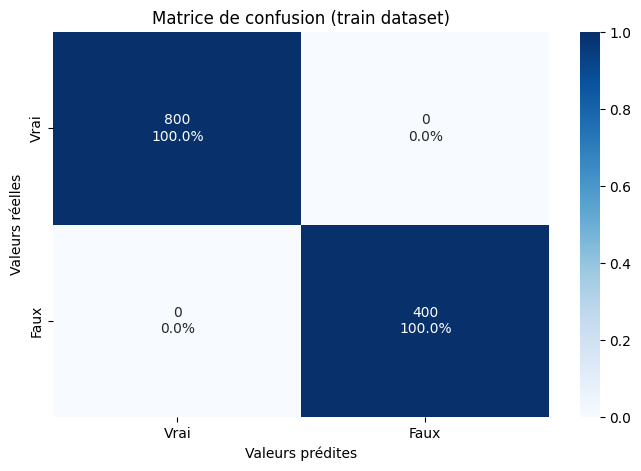

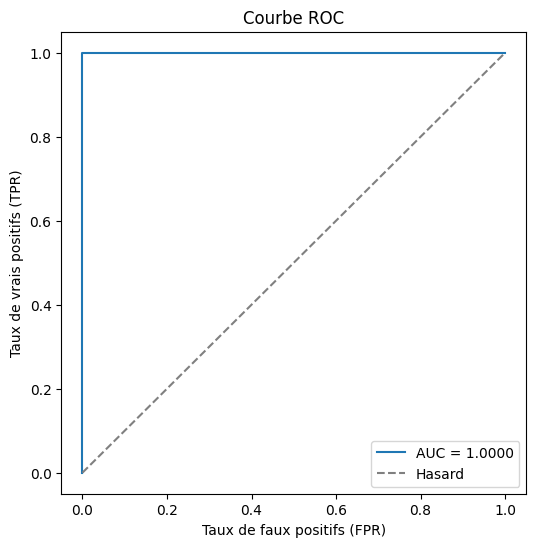

recall_score : 100.00%


In [11]:
_ = evaluate_model(model, X_train, y_train, ["Vrai", "Faux"], "recall", "Matrice de confusion (train dataset)")

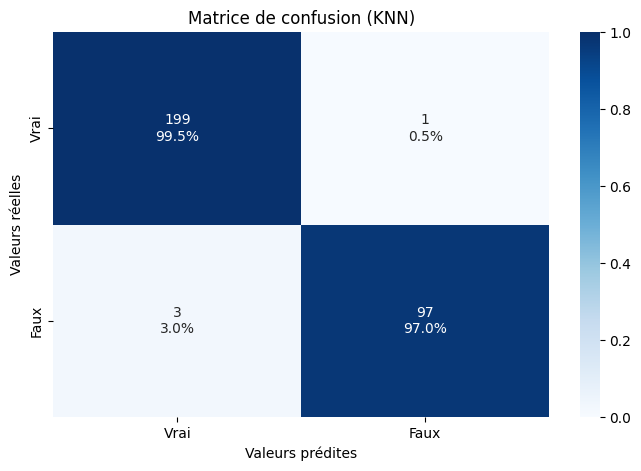

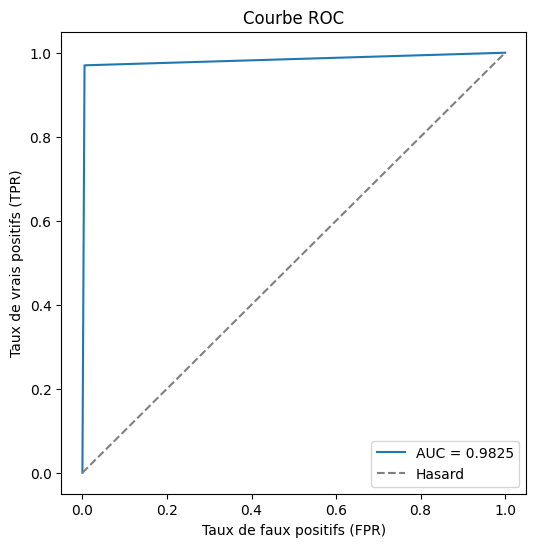

recall_score : 97.00%


In [12]:
_ = evaluate_model(model, X_test, y_test, ["Vrai", "Faux"], "recall", "Matrice de confusion (KNN)")